# Project Framework: CRISP-DM

This project follows the CRISP-DM framework, a structured process commonly used in data science and machine learning projects. CRISP-DM helps organize the project from problem definition to model evaluation and deployment considerations.

## 1. Business Understanding

The goal of this project is to build an AI-powered banking intent classification system that can classify customer queries into one of 77 banking-related intent classes.

In a real-world banking customer support system, correctly identifying customer intent is important because it allows the system to:

- Route customer questions to the correct support workflow
- Reduce manual customer service workload
- Improve response time and customer experience
- Support automation in banking chatbots and virtual assistants

Since banking data may contain sensitive personal and financial information, this project also considers PII protection as part of a production-ready AI workflow.

## 2. Data Understanding

The dataset used in this project is the Banking77 dataset. It contains customer banking queries labeled with 77 different intent categories.

During this stage, we will explore:

- Number of training and test examples
- Number of unique intent classes
- Distribution of examples across intent classes
- Text length distribution
- Sample customer queries from different intents
- Potential ambiguity between similar banking intents

## 3. Data Preparation

Before training machine learning models, the text data needs to be cleaned and prepared.

This stage includes:

- Loading train and test datasets
- Checking missing values and duplicates
- Detecting and masking potential PII such as emails, phone numbers, account numbers, and card numbers
- Encoding intent labels into numerical format
- Creating text features for the MLP baseline using TF-IDF
- Tokenizing text for transformer-based modeling

## 4. Modeling

This project compares two modeling approaches:

### Baseline Model: TF-IDF + MLP

The first model is a traditional machine learning/deep learning baseline that uses TF-IDF text features and a Multi-Layer Perceptron classifier.

### Advanced Model: LoRA-RoBERTa

The second model finetunes a RoBERTa transformer using Low-Rank Adaptation (LoRA). LoRA enables parameter-efficient finetuning by training only a small number of adapter parameters while keeping most of the pretrained transformer frozen.

## 5. Evaluation

Model performance will be evaluated using classification metrics suitable for a multi-class intent classification task.

The main metrics include:

- Accuracy
- Macro F1-score
- Weighted F1-score
- Per-class precision, recall, and F1-score
- Confusion matrix analysis

Since the dataset contains 77 intent classes, macro F1-score is especially important because it treats all classes equally, including classes that may have fewer examples.

## 6. Deployment Considerations

Although this project focuses mainly on training and evaluation, deployment considerations are included to make the project more production-oriented.

Important deployment considerations include:

- PII masking before storing or processing user queries
- Saving trained models and label encoders
- Creating an inference pipeline for new customer queries
- Monitoring model performance over time
- Handling uncertain predictions
- Updating the model when new banking intents appear

# End-to-End Project Pipeline

The complete project pipeline is organized as follows:

```text
Customer Query
      ↓
PII Detection and Masking
      ↓
Text Cleaning and Preprocessing
      ↓
Feature Engineering / Tokenization
      ↓
Model Training
  ├── TF-IDF + MLP Baseline
  └── LoRA-RoBERTa Transformer
      ↓
Model Evaluation
      ↓
Error Analysis and Recommendations
      ↓
Deployment-Ready Inference Pipeline

In [ ]:
import os

folders = [
    "results",
    "models",
    "figures",
    "src"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully!")

Project folders created successfully!


In [ ]:
!ls

banking_classification_BERT.ipynb	    figures    requirements.txt
banking_classification_BERT_solution.ipynb  models     results
datasets				    README.md  src


# 1. Data Understanding

In this section, we load the Banking77 dataset and explore the structure of customer queries and intent labels. The goal is to understand the number of samples, number of intent classes, label distribution, query length distribution, and potential data quality issues.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv("datasets/banking77_train.csv")
test_df = pd.read_csv("datasets/banking77_test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())
display(test_df.head())

print("Train columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())

Train shape: (10003, 2)
Test shape: (3080, 2)


,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


,text,category
0,How do I locate my card?,card_arrival
1,"I still have not received my new card, I order...",card_arrival
2,I ordered a card but it has not arrived. Help ...,card_arrival
3,Is there a way to know when my card will arrive?,card_arrival
4,My card has not arrived yet.,card_arrival


Train columns: ['text', 'category']
Test columns: ['text', 'category']


In [23]:
text_col= 'text'
label_col='category'

print("Number of training samples:", len(train_df))
print("Number of test samples:", len(test_df))
print("Number of intent classes:", train_df[label_col].nunique())

print("\nMissing values in train:")
print(train_df.isnull().sum())

print("\nMissing values in test:")
print(test_df.isnull().sum())

print("\nDuplicate rows in train:", train_df.duplicated().sum())
print("Duplicate rows in test:", test_df.duplicated().sum())

Number of training samples: 10003
Number of test samples: 3080
Number of intent classes: 77

Missing values in train:
text        0
category    0
dtype: int64

Missing values in test:
text        0
category    0
dtype: int64

Duplicate rows in train: 0
Duplicate rows in test: 0


In [24]:
sample_df = train_df.sample(10, random_state=42)

for i, row in sample_df.iterrows():
    print("Query:", row[text_col])
    print("Intent:", row[label_col])
    print("-" * 80)

Query: Is it possible for me to change my PIN number?
Intent: change_pin
--------------------------------------------------------------------------------
Query: I'm not sure why my card didn't work
Intent: declined_card_payment
--------------------------------------------------------------------------------
Query: I don't think my top up worked
Intent: top_up_failed
--------------------------------------------------------------------------------
Query: Can you explain why my payment was charged a fee?
Intent: card_payment_fee_charged
--------------------------------------------------------------------------------
Query: How long does a transfer from a UK account take? I just made one and it doesn't seem to be working, wondering if everything is okay
Intent: balance_not_updated_after_bank_transfer
--------------------------------------------------------------------------------
Query: Why am I getting declines when trying to make a purchase online?
Intent: declined_transfer
-------------

In [25]:
label_counts = train_df[label_col].value_counts()

print(label_counts.head(10))
print(label_counts.tail(10))

category
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
transaction_charged_twice                           175
declined_cash_withdrawal                            173
transfer_fee_charged                                172
transfer_not_received_by_recipient                  171
balance_not_updated_after_bank_transfer             171
Name: count, dtype: int64
category
top_up_limits                  97
get_disposable_virtual_card    97
receiving_money                95
atm_support                    87
compromised_card               86
lost_or_stolen_card            82
card_swallowed                 61
card_acceptance                59
virtual_card_not_working       41
contactless_not_working        35
Name: count, dtype: int64


/tmp/ipykernel_2549/1339141035.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')


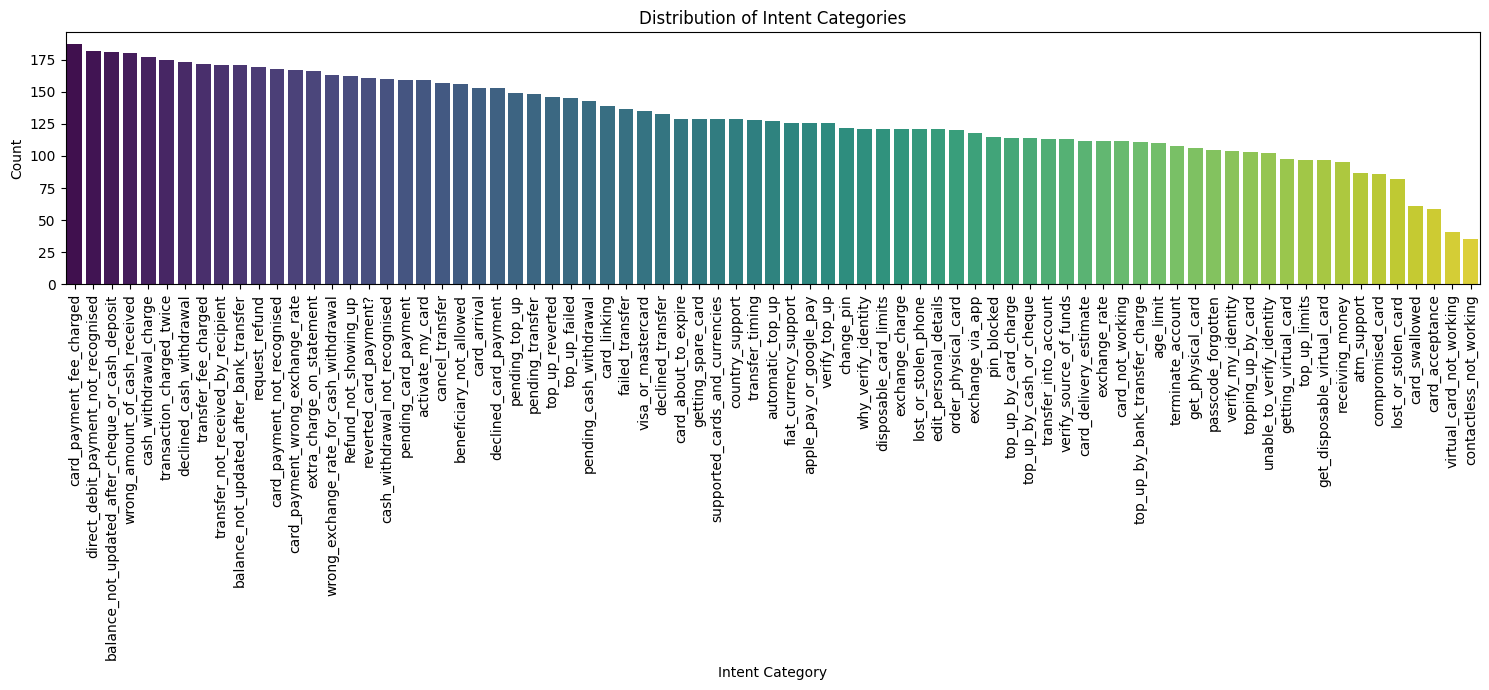

In [26]:


plt.figure(figsize=(15, 7))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title('Distribution of Intent Categories')
plt.xlabel('Intent Category')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [27]:
train_df["char_length"] = train_df[text_col].astype(str).apply(len)
train_df["word_length"] = train_df[text_col].astype(str).apply(lambda x: len(x.split()))

test_df["char_length"] = test_df[text_col].astype(str).apply(len)
test_df["word_length"] = test_df[text_col].astype(str).apply(lambda x: len(x.split()))

display(train_df[["char_length", "word_length"]].describe())

,char_length,word_length
count,10003.000000,10003.000000
mean,59.475057,11.949415
std,40.867716,7.891577
min,13.000000,2.000000
25%,36.000000,7.000000
50%,47.000000,10.000000
75%,64.000000,13.000000
max,433.000000,79.000000


In [30]:
#Average length according to intent
intent_length = (
    train_df.groupby(label_col)["word_length"]
    .mean()
    .sort_values(ascending=False)
)

display(intent_length.head(10))
display(intent_length.tail(10))

,word_length
category,
transfer_not_received_by_recipient,17.549708
transfer_fee_charged,17.395349
pending_cash_withdrawal,16.531469
failed_transfer,15.992701
direct_debit_payment_not_recognised,15.989011
transaction_charged_twice,15.988571
Refund_not_showing_up,15.808642
wrong_exchange_rate_for_cash_withdrawal,15.460123
cash_withdrawal_not_recognised,15.437500


,word_length
category,
edit_personal_details,8.471074
verify_top_up,8.309524
visa_or_mastercard,8.155556
order_physical_card,7.875000
exchange_rate,7.830357
top_up_limits,7.742268
get_physical_card,7.707547
passcode_forgotten,7.695238
atm_support,7.689655


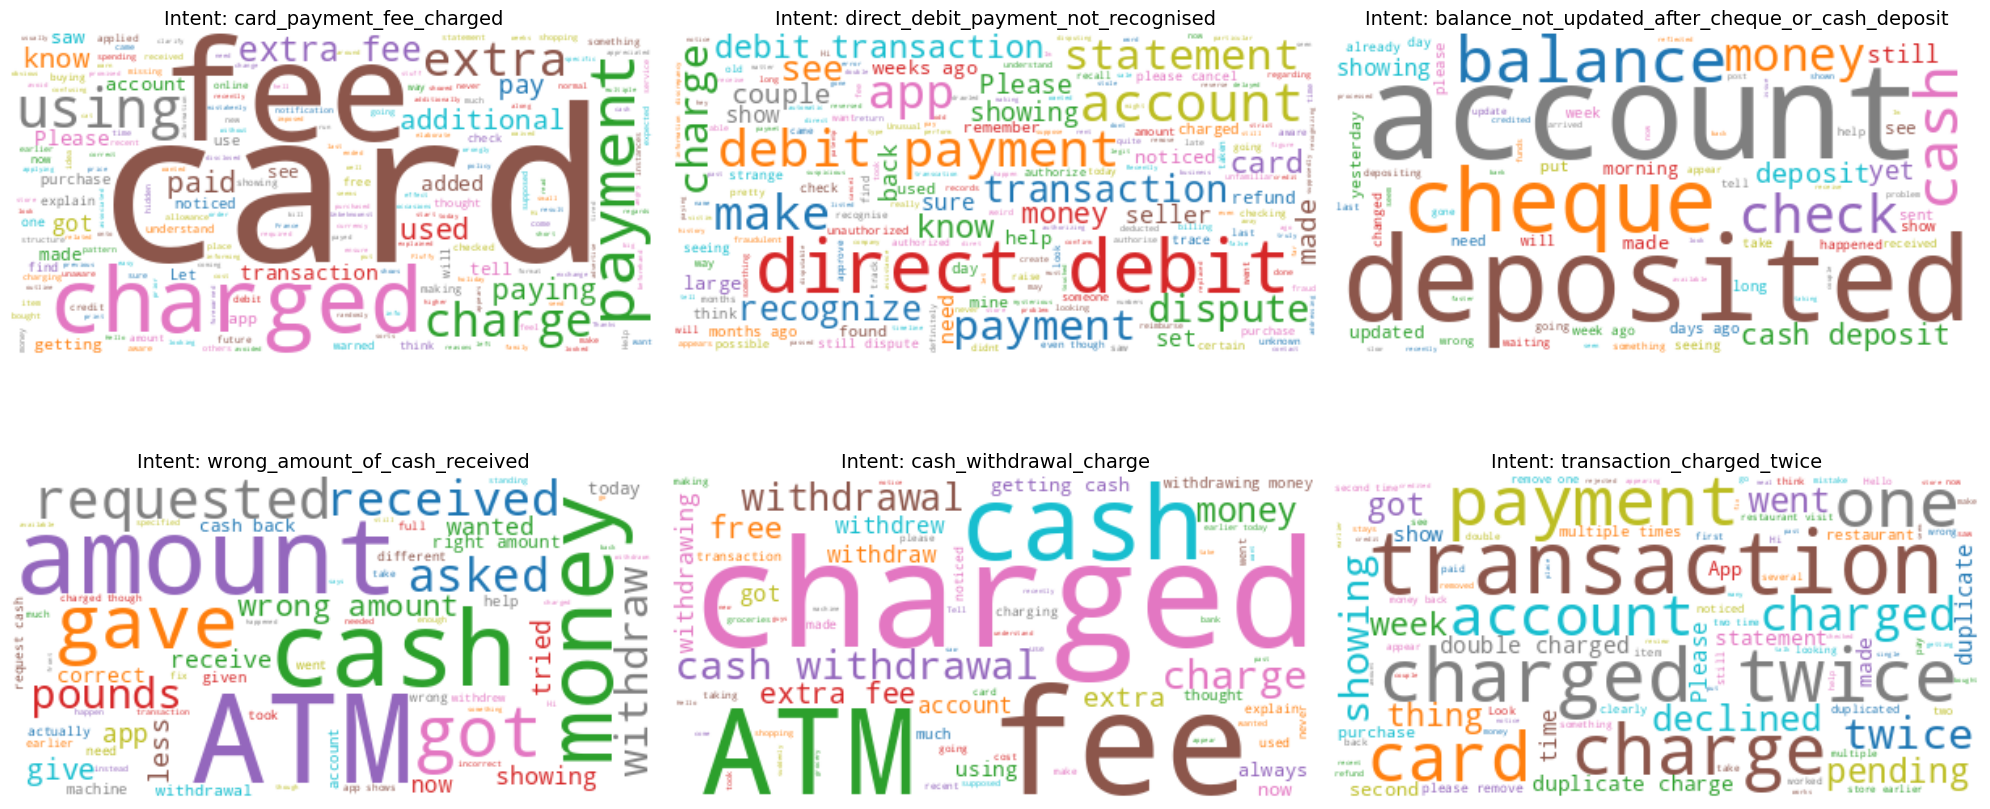

In [33]:
from wordcloud import WordCloud

# Select top 6 intents by frequency to visualize
top_intents = train_df[label_col].value_counts().nlargest(6).index

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, intent in enumerate(top_intents):
    # Combine all text for the specific intent
    text = " ".join(train_df[train_df[label_col] == intent][text_col])

    # Generate word cloud
    wc = WordCloud(width=400, height=200, background_color='white', colormap='tab10').generate(text)

    # Plot
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f"Intent: {intent}", fontsize=14)
    axes[i].axis('off')
plt.savefig("figures/wordCloudIntent_distribution.png", dpi=300)
plt.tight_layout()
plt.show()

## Word Cloud Analysis by Intent

The word clouds show that each banking intent contains several highly distinctive keywords that are strongly related to its label.

For example, the `card_payment_fee_charged` intent is dominated by words such as "fee", "charged", "card", "payment", and "extra", which clearly reflect customer concerns about unexpected card payment fees. Similarly, `direct_debit_payment_not_recognised` contains important terms such as "direct debit", "payment", "account", and "recognise", indicating that customers are reporting unfamiliar direct debit transactions.

The `balance_not_updated_after_cheque_or_cash_deposit` intent shows frequent words such as "account", "deposited", "cheque", "cash", and "balance", which are directly related to delayed account balance updates after deposits. For `wrong_amount_cash_received`, the words "ATM", "cash", "amount", "received", and "requested" suggest that customers are describing cases where the withdrawn amount was different from what they expected.

The `cash_withdrawal_charge` intent is strongly associated with "charged", "fee", "cash withdrawal", and "ATM", while `transaction_charged_twice` contains terms such as "transaction", "payment", "charged twice", "card", and "account".

Overall, the word clouds confirm that many intent classes have meaningful and interpretable keyword patterns. This suggests that traditional text features such as TF-IDF may provide a reasonable baseline. However, several intents share overlapping terms such as "fee", "charged", "payment", "cash", "card", and "account". These overlaps may cause confusion for simpler models, especially when intents are semantically similar. Therefore, a transformer-based model such as RoBERTa with LoRA finetuning is expected to better capture context and distinguish between closely related banking intents.

These visualizations indicate that banking intent classification is highly keyword-driven, but overlapping financial terms across similar intents make contextual understanding important for strong classification performance.

During data understanding, i explored the number of examples, number of intent classes, label distribution, query length distribution, and representative keywords for selected intents. The analysis shows that many classes contain distinctive keywords, but several banking intents share overlapping terms such as "payment", "charged", "fee", "card", and "account".

In [ ]:
!git status
!git add banking_classification_BERT.ipynb figures/
!git commit -m "Add data understanding and EDA"
!git push

# 2. Multi-Layer Perceptron: Preprocessing

The first model in this project is a Multi-Layer Perceptron baseline. Since MLPs cannot directly process raw text, we first convert customer queries into numerical feature vectors using TF-IDF.

This baseline helps establish a strong non-contextual benchmark before training a more advanced transformer-based model.

In [37]:
import re

def clean_text(text):
    """
    This function lowercases text, removes extra whitespace,
    and keeps the sentence mostly intact for TF-IDF features.
    """
    text = str(text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text


train_df["clean_text"] = train_df[text_col].apply(clean_text)
test_df["clean_text"] = test_df[text_col].apply(clean_text)

display(train_df[[text_col, "clean_text", label_col]].head())

,text,clean_text,category
0,I am still waiting on my card?,i am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,what can i do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,i have been waiting over a week. is the card s...,card_arrival
3,Can I track my card while it is in the process...,can i track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...","how do i know if i will get my card, or if it ...",card_arrival


In [43]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
train_df["label_id"] = label_encoder.fit_transform(train_df[label_col])
test_df["label_id"] = label_encoder.transform(test_df[label_col])

num_labels = len(label_encoder.classes_)

print("Number of classes:", num_labels)
print("First 10 label mappings:")

for idx, label in enumerate(label_encoder.classes_[:10]):
    print(idx, "->", label)

Number of classes: 77
First 10 label mappings:
0 -> Refund_not_showing_up
1 -> activate_my_card
2 -> age_limit
3 -> apple_pay_or_google_pay
4 -> atm_support
5 -> automatic_top_up
6 -> balance_not_updated_after_bank_transfer
7 -> balance_not_updated_after_cheque_or_cash_deposit
8 -> beneficiary_not_allowed
9 -> cancel_transfer


In [48]:
from sklearn.model_selection import train_test_split

X = train_df["clean_text"]
y = train_df["label_id"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

X_test = test_df["clean_text"]
y_test = test_df["label_id"]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (8502,)
X_val: (1501,)
X_test: (3080,)
y_train: (8502,)
y_val: (1501,)
y_test: (3080,)


In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF validation shape:", X_val_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

TF-IDF train shape: (8502, 9232)
TF-IDF validation shape: (1501, 9232)
TF-IDF test shape: (3080, 9232)


- Take a maximum of 10,000 important words/phrases
- use both unigram and bigram

In [51]:
import joblib
os.makedirs("models/mlp_baseline", exist_ok=True)

joblib.dump(label_encoder, "models/mlp_baseline/label_encoder.joblib")
joblib.dump(tfidf_vectorizer, "models/mlp_baseline/tfidf_vectorizer.joblib")

print("Saved label encoder and TF-IDF vectorizer.")

Saved label encoder and TF-IDF vectorizer.


# 3. Multi-Layer Perceptron: Training and Evaluation

In this section, we build and train a Multi-Layer Perceptron baseline model using PyTorch. The model takes TF-IDF vectors as input and predicts one of the 77 banking intent classes.

The MLP baseline is used as a non-contextual benchmark before training a more advanced transformer-based model.

In [52]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from tqdm.auto import tqdm
import joblib
import json
import os

In [53]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [54]:
class TfidfDataset(Dataset):
    def __init__(self, X_tfidf, y):
        self.X = X_tfidf.tocsr()
        self.y = np.array(y, dtype=np.int64)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx].toarray().squeeze().astype(np.float32)
        y = self.y[idx]

        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

In [55]:
class TfidfDataset(Dataset):
    def __init__(self, X_tfidf, y):
        self.X = X_tfidf.tocsr()
        self.y = np.array(y, dtype=np.int64)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx].toarray().squeeze().astype(np.float32)
        y = self.y[idx]

        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

In [56]:
train_dataset = TfidfDataset(X_train_tfidf, y_train)
val_dataset = TfidfDataset(X_val_tfidf, y_val)
test_dataset = TfidfDataset(X_test_tfidf, y_test)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 8502
Validation dataset size: 1501
Test dataset size: 3080


In [57]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [58]:
class MLPTextClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, dropout_rate=0.3):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [59]:
input_dim = X_train_tfidf.shape[1]
hidden_dim = 512
num_classes = num_labels

mlp_model = MLPTextClassifier(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    num_classes=num_classes,
    dropout_rate=0.3
).to(device)

print(mlp_model)
print("Input dimension:", input_dim)
print("Number of classes:", num_classes)

MLPTextClassifier(
  (model): Sequential(
    (0): Linear(in_features=9232, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=77, bias=True)
  )
)
Input dimension: 9232
Number of classes: 77


In [60]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    mlp_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [61]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    total_loss = 0
    all_preds = []
    all_labels = []

    for batch_x, batch_y in tqdm(dataloader, desc="Training", leave=False):
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        logits = model(batch_x)
        loss = criterion(logits, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(batch_y.detach().cpu().numpy())

    avg_loss = total_loss / len(dataloader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return avg_loss, accuracy, macro_f1


def evaluate_model(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_x, batch_y in tqdm(dataloader, desc="Evaluating", leave=False):
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_x)
            loss = criterion(logits, batch_y)

            total_loss += loss.item() * batch_x.size(0)

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(batch_y.detach().cpu().numpy())

    avg_loss = total_loss / len(dataloader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

    return avg_loss, accuracy, macro_f1, weighted_f1, all_preds, all_labels

In [62]:
num_epochs = 10

history = {
    "train_loss": [],
    "train_accuracy": [],
    "train_macro_f1": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_macro_f1": [],
    "val_weighted_f1": []
}

best_val_macro_f1 = 0.0
best_model_path = "models/mlp_baseline/best_mlp_model.pt"

os.makedirs("models/mlp_baseline", exist_ok=True)

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")

    train_loss, train_acc, train_macro_f1 = train_one_epoch(
        mlp_model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc, val_macro_f1, val_weighted_f1, _, _ = evaluate_model(
        mlp_model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)
    history["train_macro_f1"].append(train_macro_f1)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)
    history["val_macro_f1"].append(val_macro_f1)
    history["val_weighted_f1"].append(val_weighted_f1)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train Macro F1: {train_macro_f1:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val Macro F1:   {val_macro_f1:.4f}")

    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        torch.save(mlp_model.state_dict(), best_model_path)
        print("Best model saved.")


Epoch 1/10


Training:   0%|          | 0/133 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]

Train Loss: 3.7484 | Train Acc: 0.1488 | Train Macro F1: 0.1305
Val Loss:   2.1345 | Val Acc:   0.5583 | Val Macro F1:   0.4632
Best model saved.

Epoch 2/10


Training:   0%|          | 0/133 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]

Train Loss: 0.0326 | Train Acc: 0.9932 | Train Macro F1: 0.9931
Val Loss:   0.4974 | Val Acc:   0.8714 | Val Macro F1:   0.8711

Epoch 10/10


Training:   0%|          | 0/133 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]

Train Loss: 0.0287 | Train Acc: 0.9942 | Train Macro F1: 0.9941
Val Loss:   0.5148 | Val Acc:   0.8701 | Val Macro F1:   0.8712


In [63]:
history_df = pd.DataFrame(history)
display(history_df)

,train_loss,train_accuracy,train_macro_f1,val_loss,val_accuracy,val_macro_f1,val_weighted_f1
0,3.748399,0.148789,0.130524,2.134544,0.558294,0.463250,0.512951
1,1.168480,0.710892,0.678886,0.684468,0.821452,0.798373,0.816688
2,0.412078,0.899906,0.891728,0.509383,0.860093,0.854072,0.857540
3,0.213314,0.949071,0.947087,0.456852,0.872751,0.870368,0.872125
4,0.124273,0.972359,0.971074,0.468401,0.870087,0.868471,0.869611
5,0.082712,0.981181,0.979892,0.456456,0.872085,0.872404,0.872042
6,0.063225,0.984827,0.984391,0.489988,0.871419,0.871060,0.871802
7,0.045976,0.989767,0.989188,0.499974,0.866755,0.866153,0.866633
8,0.032612,0.993178,0.993054,0.497427,0.871419,0.871076,0.871257
9,0.028675,0.994237,0.994134,0.514843,0.870087,0.871205,0.870284


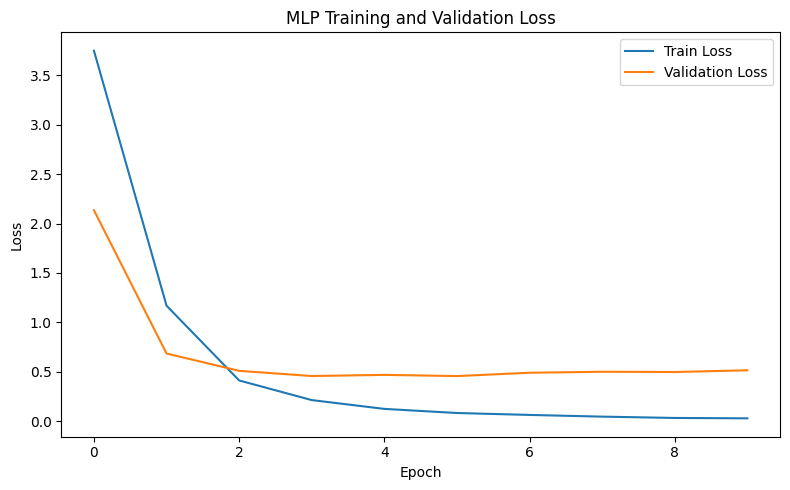

In [64]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["train_loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("MLP Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("figures/mlp_loss_curve.png", dpi=300)
plt.show()

In [65]:
best_mlp_model = MLPTextClassifier(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    num_classes=num_classes,
    dropout_rate=0.3
).to(device)

best_mlp_model.load_state_dict(torch.load(best_model_path, map_location=device))
best_mlp_model.eval()

test_loss, test_acc, test_macro_f1, test_weighted_f1, test_preds, test_labels = evaluate_model(
    best_mlp_model,
    test_loader,
    criterion,
    device
)

print("MLP Test Results")
print("-" * 50)
print(f"Test Loss:        {test_loss:.4f}")
print(f"Test Accuracy:    {test_acc:.4f}")
print(f"Test Macro F1:    {test_macro_f1:.4f}")
print(f"Test Weighted F1: {test_weighted_f1:.4f}")

/tmp/ipykernel_2549/178283460.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_mlp_model.load_state_dict(torch.load(best_model_path, map_location=device))


Evaluating:   0%|          | 0/49 [00:00<?, ?it/s]

MLP Test Results
--------------------------------------------------
Test Loss:        0.4256
Test Accuracy:    0.8851
Test Macro F1:    0.8855
Test Weighted F1: 0.8855


In [66]:
class_names = label_encoder.classes_

mlp_report = classification_report(
    test_labels,
    test_preds,
    target_names=class_names,
    zero_division=0
)

print(mlp_report)

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.95      0.93      0.94        40
                                activate_my_card       0.97      0.95      0.96        40
                                       age_limit       1.00      1.00      1.00        40
                         apple_pay_or_google_pay       1.00      1.00      1.00        40
                                     atm_support       0.97      0.90      0.94        40
                                automatic_top_up       1.00      0.88      0.93        40
         balance_not_updated_after_bank_transfer       0.67      0.75      0.71        40
balance_not_updated_after_cheque_or_cash_deposit       0.92      0.85      0.88        40
                         beneficiary_not_allowed       0.92      0.85      0.88        40
                                 cancel_transfer       0.97      0.93      0.95        40
         

In [67]:
os.makedirs("results", exist_ok=True)

with open("results/mlp_classification_report.txt", "w") as f:
    f.write(mlp_report)

mlp_metrics = {
    "model": "TF-IDF + MLP",
    "test_loss": float(test_loss),
    "test_accuracy": float(test_acc),
    "test_macro_f1": float(test_macro_f1),
    "test_weighted_f1": float(test_weighted_f1)
}

with open("results/mlp_metrics.json", "w") as f:
    json.dump(mlp_metrics, f, indent=4)

print("Saved MLP metrics and classification report.")

Saved MLP metrics and classification report.


In [68]:
test_results_df = test_df.copy()

test_results_df["true_label_id"] = test_labels
test_results_df["pred_label_id"] = test_preds

test_results_df["true_intent"] = label_encoder.inverse_transform(test_results_df["true_label_id"])
test_results_df["predicted_intent"] = label_encoder.inverse_transform(test_results_df["pred_label_id"])

test_results_df["correct"] = test_results_df["true_label_id"] == test_results_df["pred_label_id"]

display(test_results_df[[text_col, "true_intent", "predicted_intent", "correct"]].head(20))

,text,true_intent,predicted_intent,correct
0,How do I locate my card?,card_arrival,get_physical_card,False
1,"I still have not received my new card, I order...",card_arrival,card_arrival,True
2,I ordered a card but it has not arrived. Help ...,card_arrival,transfer_not_received_by_recipient,False
3,Is there a way to know when my card will arrive?,card_arrival,card_arrival,True
4,My card has not arrived yet.,card_arrival,card_arrival,True
5,When will I get my card?,card_arrival,card_delivery_estimate,False
6,Do you know if there is a tracking number for ...,card_arrival,card_arrival,True
7,i have not received my card,card_arrival,card_arrival,True
8,still waiting on that card,card_arrival,card_arrival,True
9,Is it normal to have to wait over a week for m...,card_arrival,card_arrival,True


In [69]:
test_results_df.to_csv("results/mlp_test_predictions.csv", index=False)

print("Saved test predictions to results/mlp_test_predictions.csv")

Saved test predictions to results/mlp_test_predictions.csv


Analyze incorrect predictions

In [70]:
incorrect_df = test_results_df[test_results_df["correct"] == False]

print("Number of incorrect predictions:", len(incorrect_df))
print("Number of correct predictions:", test_results_df["correct"].sum())

display(incorrect_df[[text_col, "true_intent", "predicted_intent"]].head(20))

Number of incorrect predictions: 354
Number of correct predictions: 2726


,text,true_intent,predicted_intent
0,How do I locate my card?,card_arrival,get_physical_card
2,I ordered a card but it has not arrived. Help ...,card_arrival,transfer_not_received_by_recipient
5,When will I get my card?,card_arrival,card_delivery_estimate
11,How long does a card delivery take?,card_arrival,card_delivery_estimate
37,Is there tracking info available?,card_arrival,why_verify_identity
47,How do I add the card to my account?,card_linking,topping_up_by_card
93,Is it a good time to exchange?,exchange_rate,card_payment_wrong_exchange_rate
121,I made a currency exchange and think I was cha...,card_payment_wrong_exchange_rate,transaction_charged_twice
123,The exchange rate was wrong when I bought some...,card_payment_wrong_exchange_rate,wrong_exchange_rate_for_cash_withdrawal
138,Why am I being charged more ?,card_payment_wrong_exchange_rate,card_payment_fee_charged


## MLP Baseline Evaluation Summary

The TF-IDF + MLP baseline was trained and evaluated on the Banking77 test set. This model provides a non-contextual benchmark for the banking intent classification task.

The MLP achieved the following test performance:

- Test Accuracy: `0.8851`
- Test Macro F1: `0.8855`
- Test Weighted F1: `0.8855`

The baseline results show that TF-IDF features are useful for this dataset because many banking intents contain distinctive keywords such as "card", "cash withdrawal", "charged", "transfer", and "account". However, because the MLP relies mainly on word and phrase frequency patterns, it may struggle with intent classes that share similar vocabulary.



# 4. LoRA-RoBERTa: Preprocessing

In this section, we prepare the Banking77 dataset for finetuning a pretrained RoBERTa transformer using LoRA.

Unlike the MLP baseline, RoBERTa does not use TF-IDF features. Instead, customer queries are tokenized into subword tokens using the `roberta-base` tokenizer. The labels are encoded into integer class IDs and the dataset is converted into Hugging Face Dataset objects.

Dynamic padding is applied using `DataCollatorWithPadding`, which pads each batch based on the longest sequence in that batch. This is more efficient than padding every query to the maximum sequence length.

In [74]:
from datasets import Dataset as HFDataset
from transformers import AutoTokenizer, DataCollatorWithPadding

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np
import os
import json

In [75]:
label_encoder = LabelEncoder()

train_df["label_id"] = label_encoder.fit_transform(train_df[label_col])
test_df["label_id"] = label_encoder.transform(test_df[label_col])

num_labels = len(label_encoder.classes_)

print("Number of intent classes:", num_labels)
print("First 10 label mappings:")

for i, label in enumerate(label_encoder.classes_[:10]):
    print(i, "->", label)

Number of intent classes: 77
First 10 label mappings:
0 -> Refund_not_showing_up
1 -> activate_my_card
2 -> age_limit
3 -> apple_pay_or_google_pay
4 -> atm_support
5 -> automatic_top_up
6 -> balance_not_updated_after_bank_transfer
7 -> balance_not_updated_after_cheque_or_cash_deposit
8 -> beneficiary_not_allowed
9 -> cancel_transfer


In [76]:
os.makedirs("models/roberta_lora", exist_ok=True)

id2label = {i: label for i, label in enumerate(label_encoder.classes_)}
label2id = {label: i for i, label in enumerate(label_encoder.classes_)}

with open("models/roberta_lora/id2label.json", "w") as f:
    json.dump(id2label, f, indent=4)

with open("models/roberta_lora/label2id.json", "w") as f:
    json.dump(label2id, f, indent=4)

print("Saved label mappings.")

Saved label mappings.


In [78]:
roberta_text_col = "clean_text"

In [79]:
roberta_train_df, roberta_val_df = train_test_split(
    train_df[[roberta_text_col, "label_id"]],
    test_size=0.15,
    random_state=42,
    stratify=train_df["label_id"]
)

roberta_test_df = test_df[[roberta_text_col, "label_id"]].copy()

print("RoBERTa train shape:", roberta_train_df.shape)
print("RoBERTa validation shape:", roberta_val_df.shape)
print("RoBERTa test shape:", roberta_test_df.shape)

RoBERTa train shape: (8502, 2)
RoBERTa validation shape: (1501, 2)
RoBERTa test shape: (3080, 2)


In [80]:
roberta_train_df = roberta_train_df.rename(
    columns={roberta_text_col: "text", "label_id": "labels"}
)

roberta_val_df = roberta_val_df.rename(
    columns={roberta_text_col: "text", "label_id": "labels"}
)

roberta_test_df = roberta_test_df.rename(
    columns={roberta_text_col: "text", "label_id": "labels"}
)

display(roberta_train_df.head())

,text,labels
6898,where can i update my pin number?,22
2067,what is the reason that my top-up is still pen...,48
8168,can i use my virtual card to complete transact...,72
975,what fiat currencies are used for holdings?,37
9665,"apple watch top up help, please?",3


In [81]:
train_dataset_hf = HFDataset.from_pandas(roberta_train_df.reset_index(drop=True))
val_dataset_hf = HFDataset.from_pandas(roberta_val_df.reset_index(drop=True))
test_dataset_hf = HFDataset.from_pandas(roberta_test_df.reset_index(drop=True))

print(train_dataset_hf)
print(val_dataset_hf)
print(test_dataset_hf)

Dataset({
    features: ['text', 'labels'],
    num_rows: 8502
})
Dataset({
    features: ['text', 'labels'],
    num_rows: 1501
})
Dataset({
    features: ['text', 'labels'],
    num_rows: 3080
})


In [82]:
model_checkpoint = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

print("Tokenizer:", tokenizer.__class__.__name__)
print("Model max length:", tokenizer.model_max_length)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer: RobertaTokenizerFast
Model max length: 512


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [83]:
max_length = 256

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=max_length
    )

In [84]:
tokenized_train_dataset = train_dataset_hf.map(
    tokenize_function,
    batched=True
)

tokenized_val_dataset = val_dataset_hf.map(
    tokenize_function,
    batched=True
)

tokenized_test_dataset = test_dataset_hf.map(
    tokenize_function,
    batched=True
)

print(tokenized_train_dataset)

Map:   0%|          | 0/8502 [00:00<?, ? examples/s]

Map:   0%|          | 0/1501 [00:00<?, ? examples/s]

Map:   0%|          | 0/3080 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 8502
})


In [85]:
example_idx = 0

print("Original text:")
print(train_dataset_hf[example_idx]["text"])

print("\nTokenized input_ids:")
print(tokenized_train_dataset[example_idx]["input_ids"])

print("\nDecoded tokens:")
print(tokenizer.decode(tokenized_train_dataset[example_idx]["input_ids"]))

print("\nLabel ID:")
print(tokenized_train_dataset[example_idx]["labels"])

print("\nIntent label:")
print(id2label[tokenized_train_dataset[example_idx]["labels"]])

Original text:
where can i update my pin number?

Tokenized input_ids:
[0, 8569, 64, 939, 2935, 127, 7756, 346, 116, 2]

Decoded tokens:
<s>where can i update my pin number?</s>

Label ID:
22

Intent label:
change_pin


In [86]:
tokenized_train_dataset = tokenized_train_dataset.remove_columns(["text"])
tokenized_val_dataset = tokenized_val_dataset.remove_columns(["text"])
tokenized_test_dataset = tokenized_test_dataset.remove_columns(["text"])



In [87]:
tokenized_train_dataset.set_format("torch")
tokenized_val_dataset.set_format("torch")
tokenized_test_dataset.set_format("torch")

print(tokenized_train_dataset[0])

{'labels': tensor(22), 'input_ids': tensor([   0, 8569,   64,  939, 2935,  127, 7756,  346,  116,    2]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])}


In [88]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)
#test
sample_batch = [tokenized_train_dataset[i] for i in range(4)]
collated_batch = data_collator(sample_batch)

print("input_ids shape:", collated_batch["input_ids"].shape)
print("attention_mask shape:", collated_batch["attention_mask"].shape)
print("labels shape:", collated_batch["labels"].shape)

input_ids shape: torch.Size([4, 15])
attention_mask shape: torch.Size([4, 15])
labels shape: torch.Size([4])


## Dynamic Padding Check

The data collator was tested on a small batch of 4 tokenized examples. The resulting batch shapes were:

- `input_ids`: `torch.Size([4, 15])`
- `attention_mask`: `torch.Size([4, 15])`
- `labels`: `torch.Size([4])`

This confirms that dynamic padding is working correctly. Instead of padding all sequences to the maximum length of 256 tokens, `DataCollatorWithPadding` pads the batch only to the longest sequence within that batch.

In this example, the longest query in the batch contains 15 tokens, so all 4 examples were padded to length 15. This makes training more efficient by reducing unnecessary padding tokens and saving memory.

The `labels` tensor has shape `[4]` because there is one intent label for each query in the batch.

## LoRA-RoBERTa Preprocessing Summary

For the LoRA-RoBERTa model, the intent labels were encoded into integer class IDs using a label encoder. The same label mapping is used across the training, validation, and test sets to ensure consistent evaluation.

Customer queries were tokenized using the `roberta-base` tokenizer from Hugging Face. The tokenizer converts raw text into subword token IDs that can be processed by RoBERTa. A maximum sequence length of 256 tokens was used, and longer queries were truncated.

Dynamic padding was applied with `DataCollatorWithPadding`. Instead of padding every query to 256 tokens, this collator pads each batch only to the length of the longest sequence in that batch. This improves computational efficiency and reduces unnecessary padding.

This preprocessing pipeline prepares the dataset for parameter-efficient finetuning with LoRA-RoBERTa.